🚕 NYC Taxi — Business Problem

## Problem Statement

Predict `trip_duration` — the total duration of a taxi trip in seconds,
based on pickup/dropoff location, time, and passenger information.

## Business Value

Accurate trip duration prediction helps taxi services optimize
route planning, improve passenger wait time estimates, and
enable dynamic pricing based on expected trip length.

In [4]:
! pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [6]:
train = pd.read_csv(r"C:\Users\user\Desktop\train.csv")
test  = pd.read_csv(r"C:\Users\user\Desktop\test.csv")

In [7]:
df = train.copy()

In [10]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [11]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [12]:
df.shape

(1458644, 11)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [14]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [15]:
df.isnull().mean().round(4)

id                    0.0
vendor_id             0.0
pickup_datetime       0.0
dropoff_datetime      0.0
passenger_count       0.0
pickup_longitude      0.0
pickup_latitude       0.0
dropoff_longitude     0.0
dropoff_latitude      0.0
store_and_fwd_flag    0.0
trip_duration         0.0
dtype: float64

In [16]:
df = df.drop(["id", "dropoff_datetime"], axis=1)

In [18]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [19]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))
df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

In [20]:
df["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

In [21]:
df.duplicated().sum()
df = df.drop_duplicates()

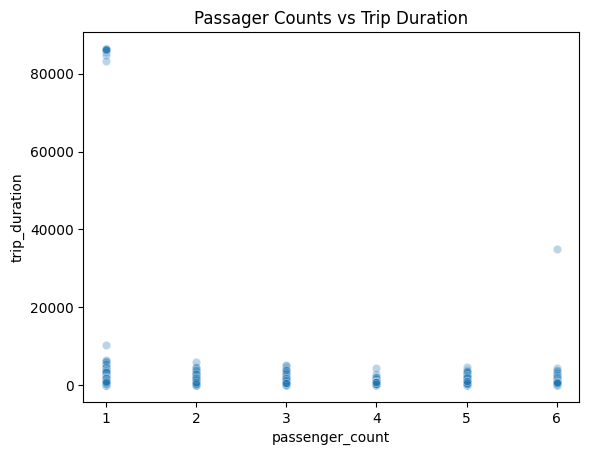

In [22]:
sns.scatterplot(data=df.sample(5000, random_state=14),
                x='passenger_count', y='trip_duration', alpha=0.3)
plt.title('Passager Counts vs Trip Duration')
plt.show()

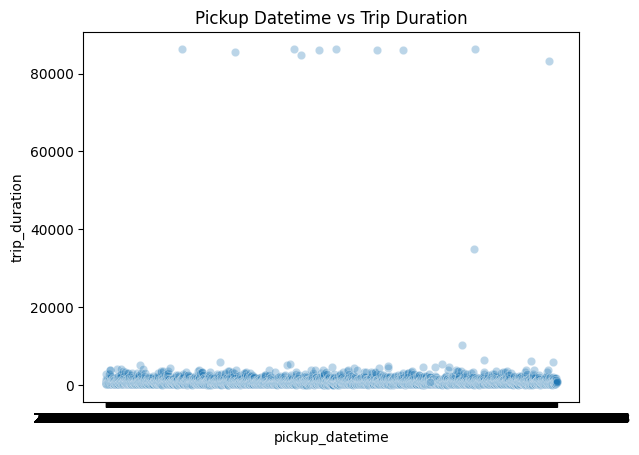

In [23]:
sns.scatterplot(data=df.sample(5000, random_state=14),
                x='pickup_datetime', y='trip_duration', alpha=0.3)
plt.title('Pickup Datetime vs Trip Duration')
plt.show()

In [24]:
cols_to_check = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
                 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

before = len(df)
for col in cols_to_check:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[~((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR))]

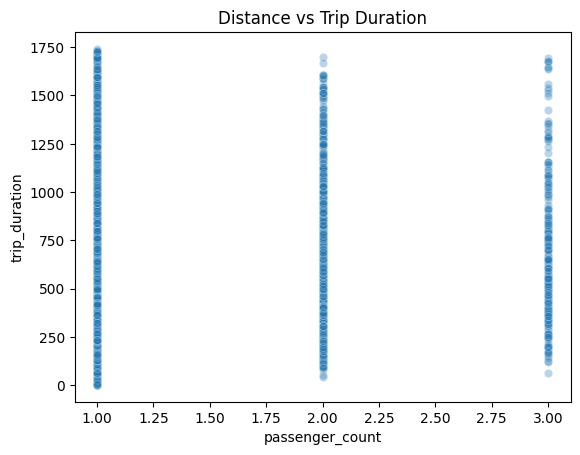

In [25]:
sns.scatterplot(data=df.sample(5000, random_state=14),
                x='passenger_count', y='trip_duration', alpha=0.3)
plt.title('Distance vs Trip Duration')
plt.show()

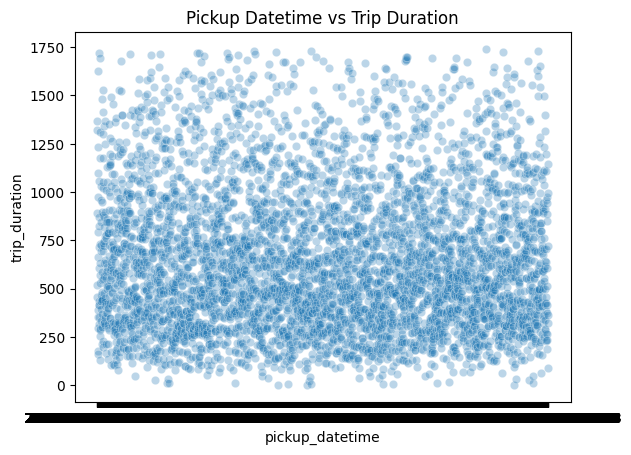

In [26]:
sns.scatterplot(data=df.sample(5000, random_state=14),
                x='pickup_datetime', y='trip_duration', alpha=0.3)
plt.title('Pickup Datetime vs Trip Duration')
plt.show()

In [27]:
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({"Y": 1, "N": 0})

In [28]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km
0,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,0,455,1.498521
1,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,0,663,1.805507
3,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,0,429,1.485498
4,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,0,435,1.188588
8,1,2016-05-27 23:12:23,1,-73.999481,40.738400,-73.985786,40.732815,0,255,1.310353


In [29]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
for col, period in [('hour', 24), ('dayofweek', 7), ('month', 12)]:
    val = getattr(df['pickup_datetime'].dt, col)
    df[f'pickup_{col}_sin'] = np.sin(2 * np.pi * val / period)
    df[f'pickup_{col}_cos'] = np.cos(2 * np.pi * val / period)
df = df.drop('pickup_datetime', axis=1)

EDA

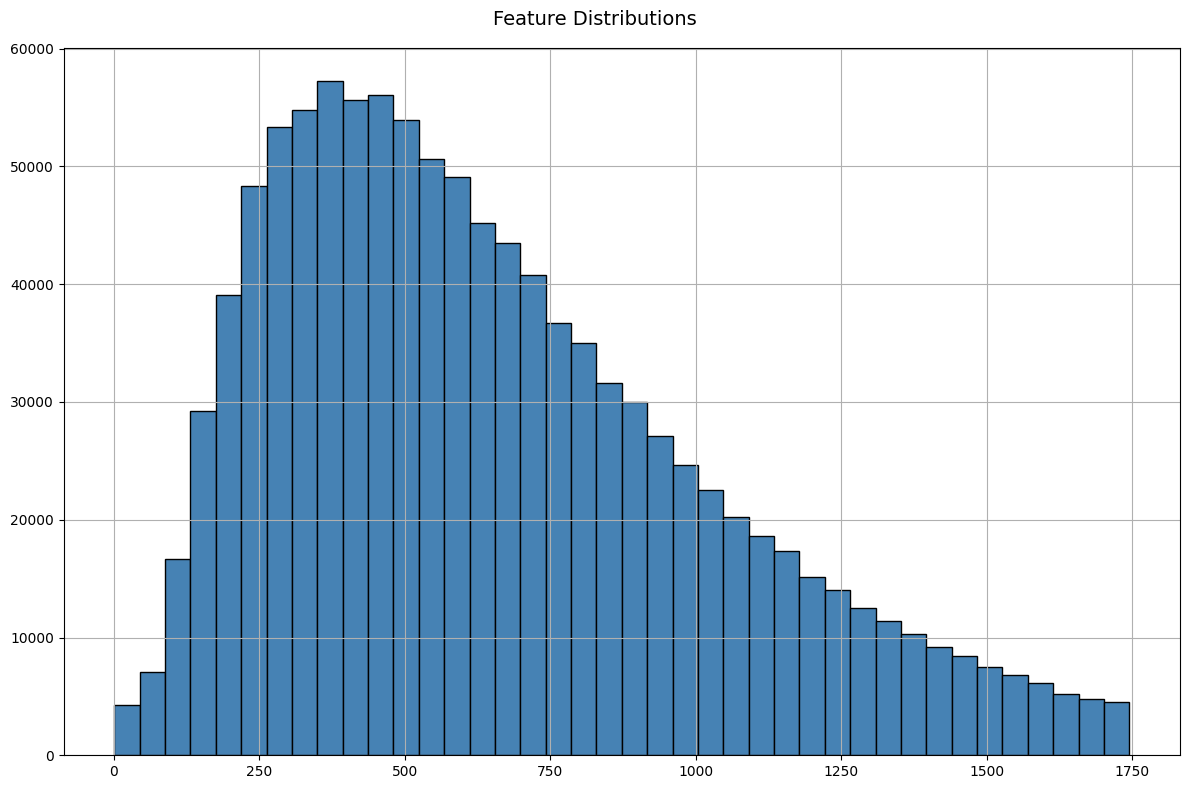

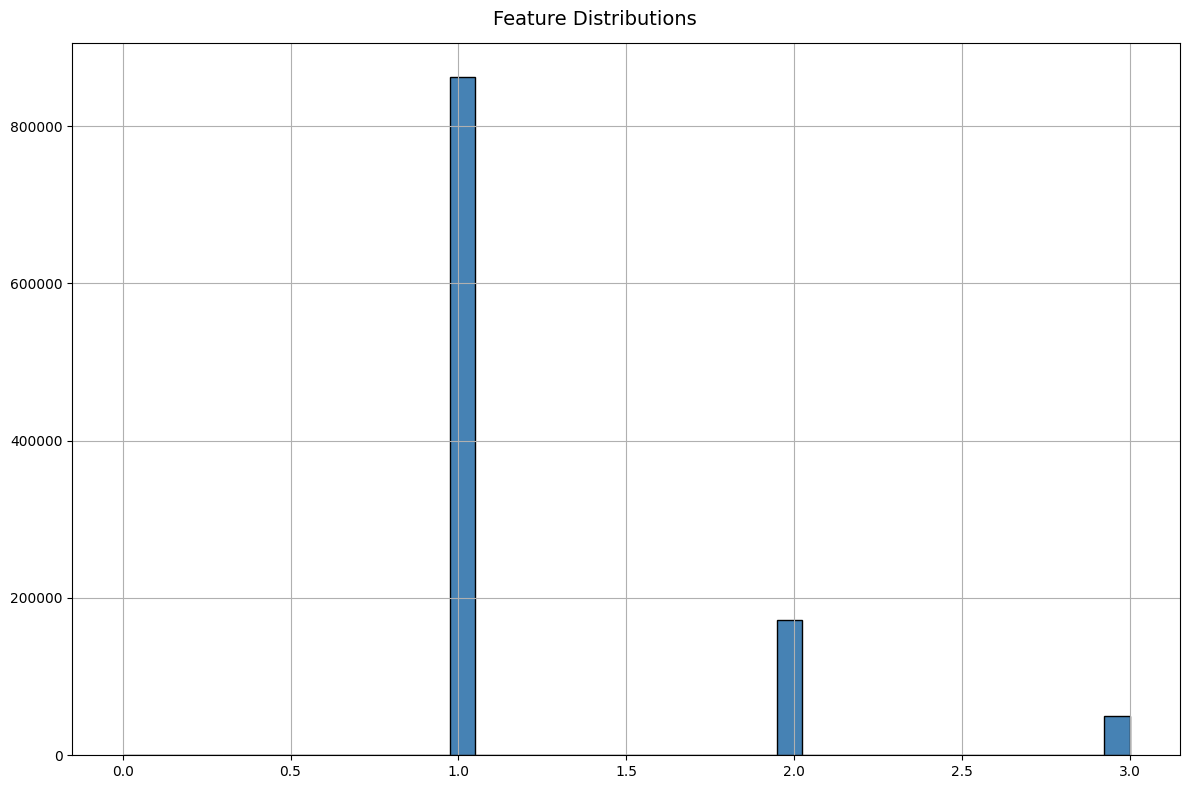

In [30]:
features = ['trip_duration', 'passenger_count']
for i in features:
  df[i].hist(
      figsize=(12, 8), bins=40, color='steelblue', edgecolor='black')
  plt.suptitle('Feature Distributions', fontsize=14)
  plt.tight_layout()
  plt.show()

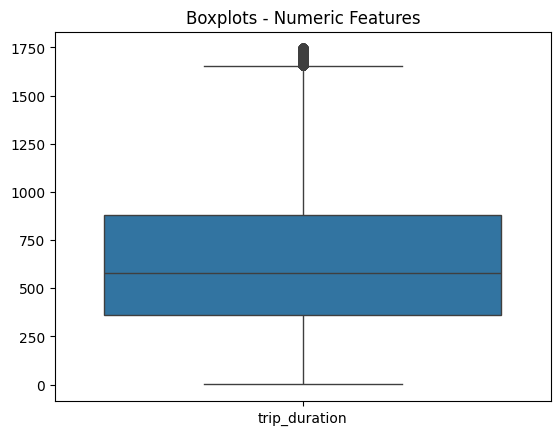

In [31]:
sns.boxplot(data=df[['trip_duration']])
plt.title('Boxplots - Numeric Features')
plt.show()

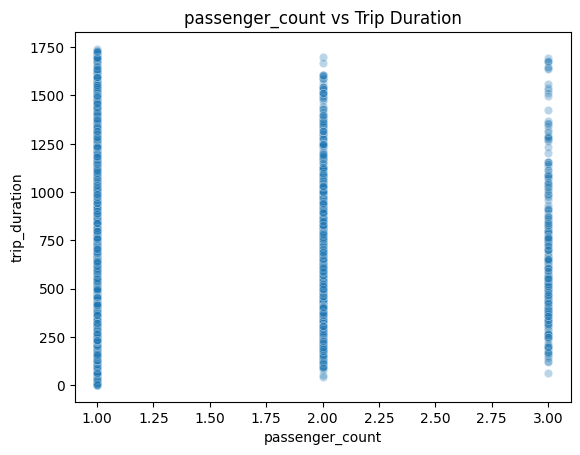

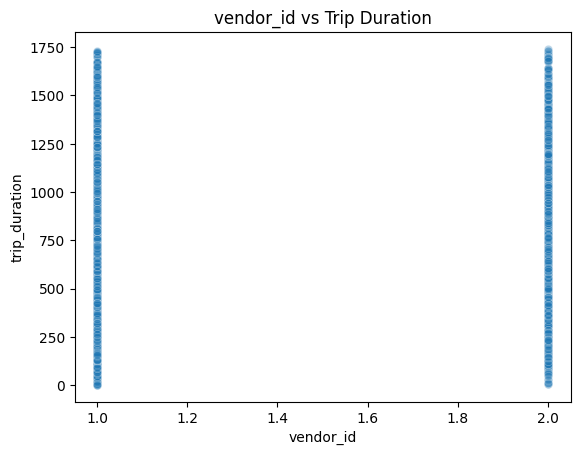

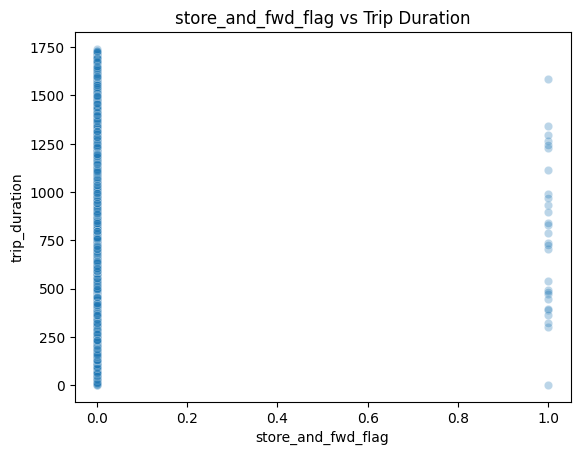

In [32]:
features = ['passenger_count', 'vendor_id', 'store_and_fwd_flag']
for i in features:
  sns.scatterplot(data=df.sample(5000, random_state=14),
                  x=i, y='trip_duration', alpha=0.3)
  plt.title(f'{i} vs Trip Duration')
  plt.show()

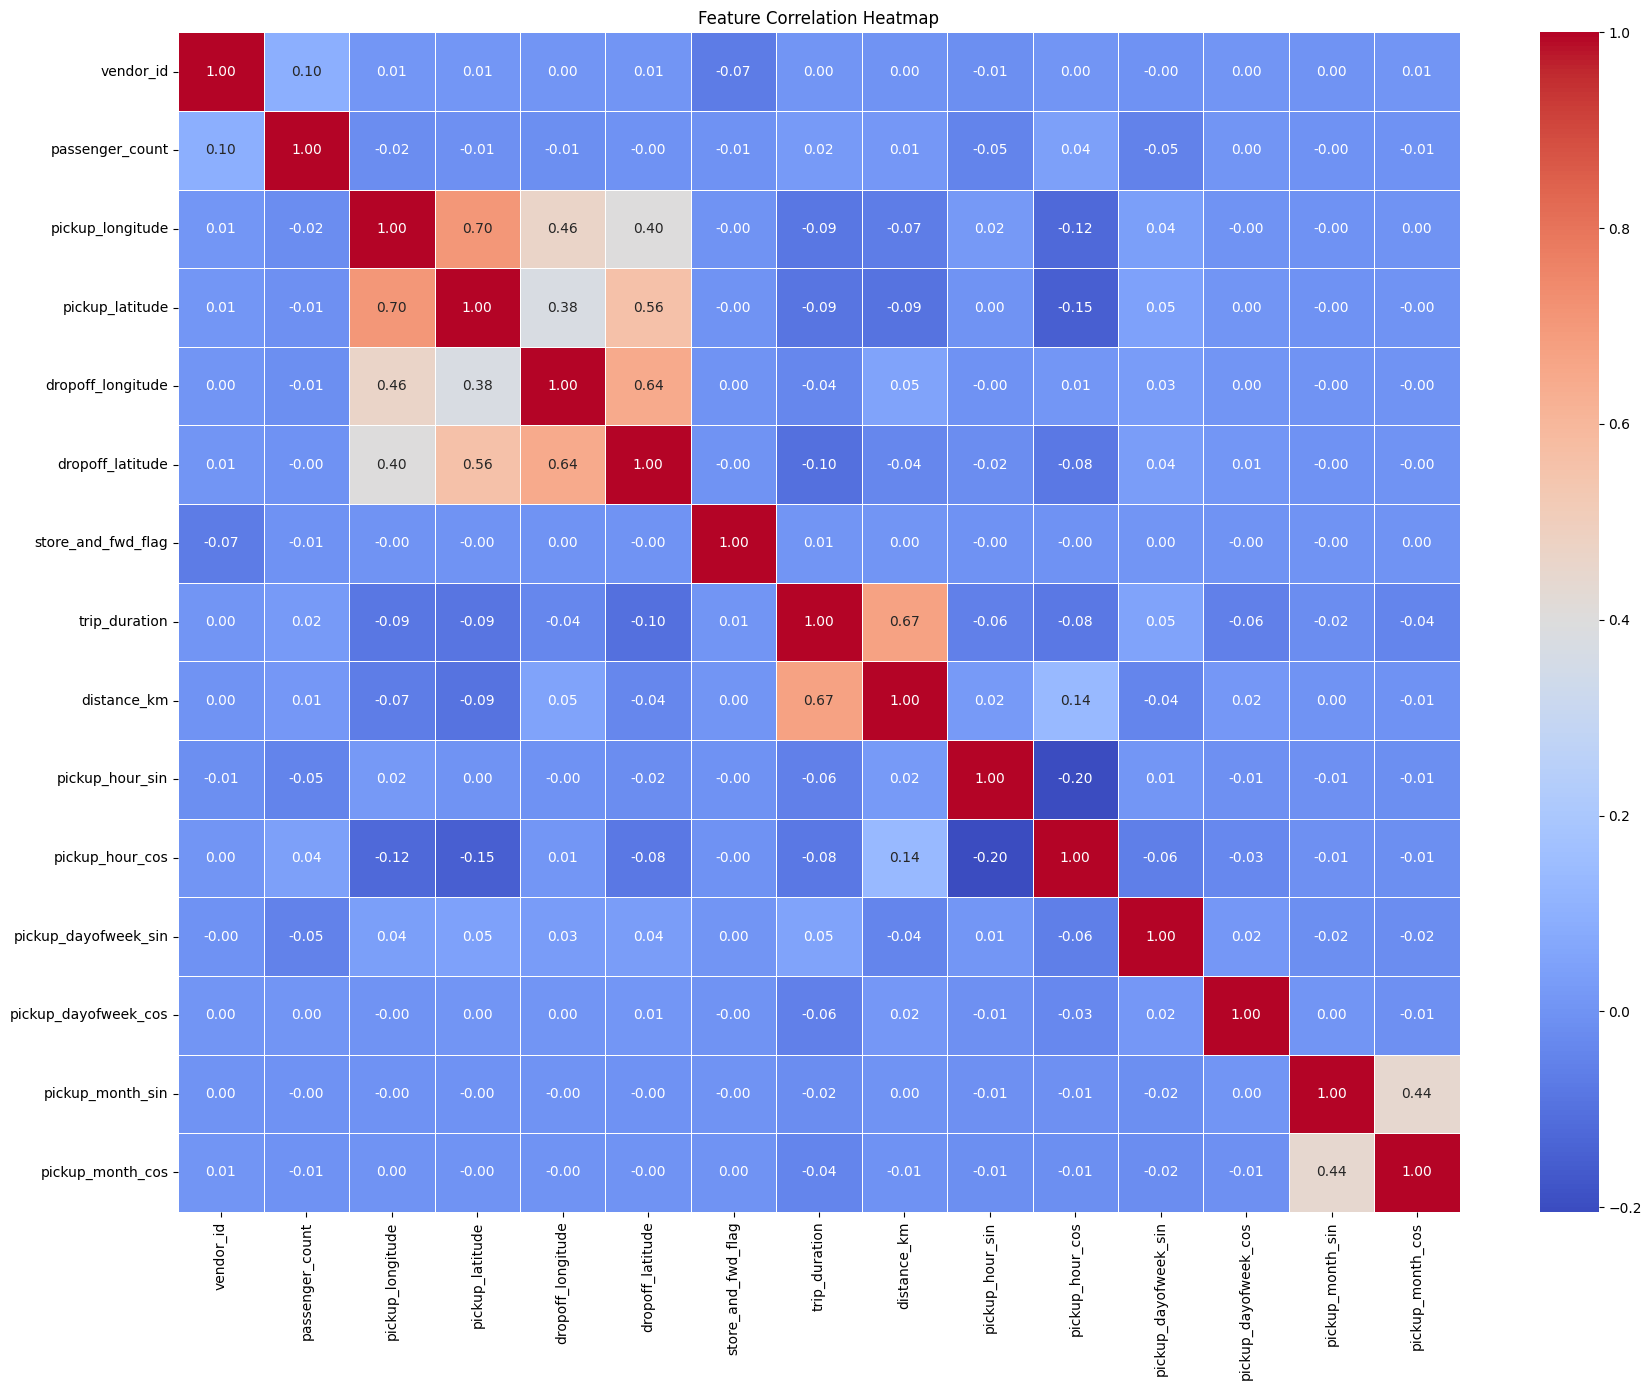

In [33]:
corr = df.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

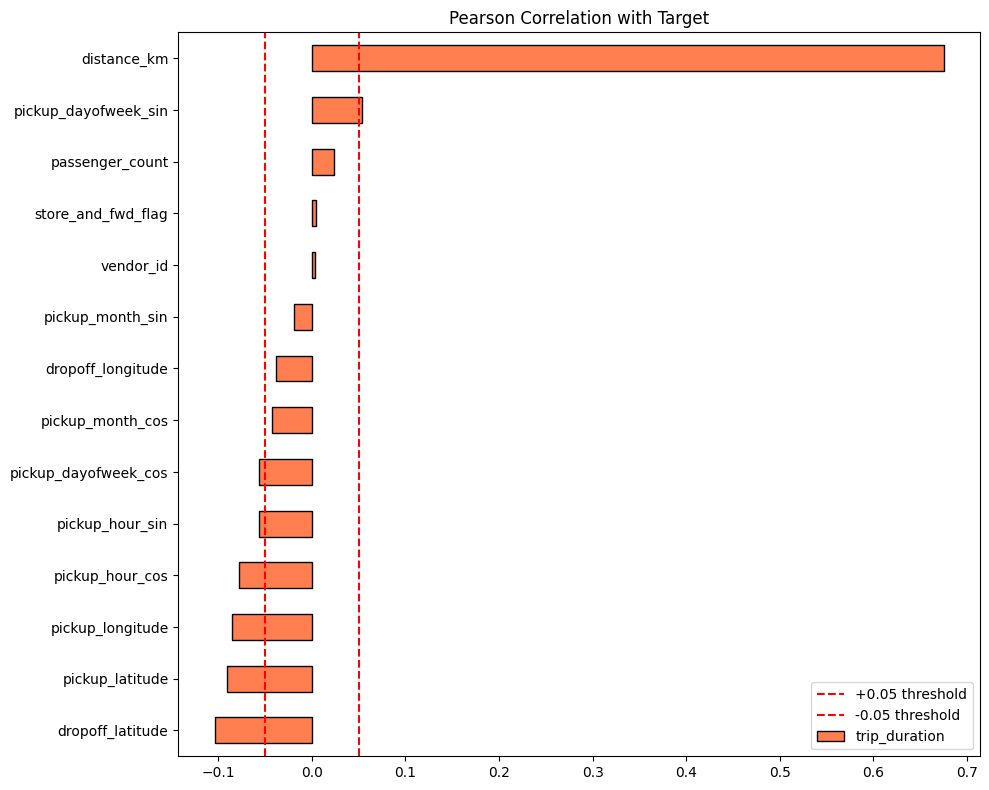

In [34]:
target = 'store_and_fwd_flag'
correlations = df.corr()["trip_duration"].drop("trip_duration").sort_values()
correlations.plot(kind='barh', figsize=(10, 8), color='coral', edgecolor='black')
plt.title('Pearson Correlation with Target')
plt.axvline(x=0.05,  color='r', linestyle='--', label='+0.05 threshold')
plt.axvline(x=-0.05, color='r', linestyle='--', label='-0.05 threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
!pip install kydavra

In [41]:
import warnings
warnings.filterwarnings('ignore')

from kydavra import LassoSelector
lasso = LassoSelector()
selected_columns = lasso.select(df, 'trip_duration')
df = df[selected_columns + ['trip_duration']]

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x = df.drop('trip_duration', axis=1)
y = df['trip_duration']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=14)

In [44]:
pipe = Pipeline([
    ('StandardScaler', StandardScaler()),
    ('PCA', PCA())
])

In [45]:
pipe.fit(x_train, y_train)
x_train = pipe.transform(x_train)
x_test = pipe.transform(x_test)

In [46]:
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=14, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=14, verbose=-1, n_jobs=-1)
}

In [47]:
from sklearn.metrics import root_mean_squared_log_error

In [48]:
result = {}
trained_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    prediction = model.predict(x_test).clip(min=0)
    print(f"{name} done ✓")

    mae   = mean_absolute_error(y_test, prediction)
    rmsle = root_mean_squared_log_error(y_test, prediction)
    r2    = r2_score(y_test, prediction)

    train_r2 = r2_score(y_train, model.predict(x_train))
    overfit  = train_r2 - r2

    result[name] = {
        'MAE': mae,
        'RMSLE': rmsle,
        'R2': r2,
        'Overfit': overfit
    }
    trained_models[name] = model

results = pd.DataFrame(result).T.sort_values('R2', ascending=False)

Linear Regression done ✓
XGBoost done ✓
LightGBM done ✓


In [49]:
results

,MAE,RMSLE,R2,Overfit
XGBoost,148.174515,0.386349,0.704729,0.009876
LightGBM,154.284154,0.401163,0.686138,0.002248
Linear Regression,195.677110,0.481306,0.519880,0.001715


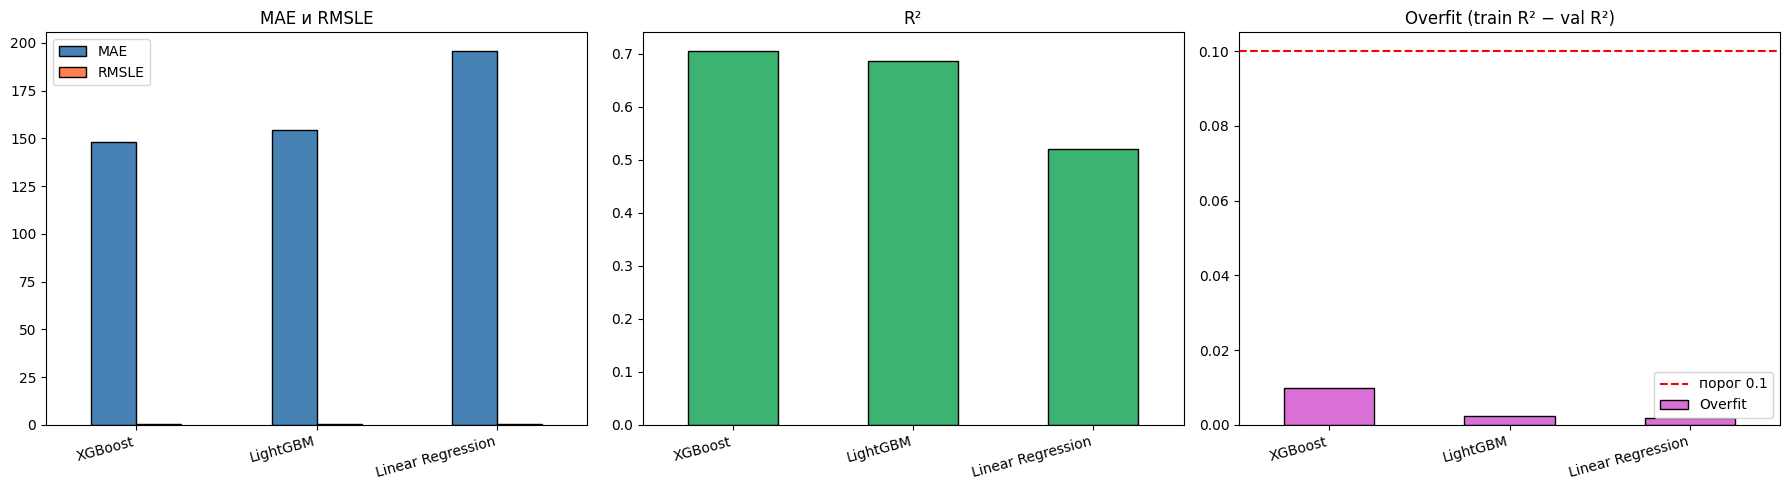

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results[['MAE', 'RMSLE']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('MAE и RMSLE')
axes[0].set_xticklabels(results.index, rotation=15, ha='right')

results[['R2']].plot(
    kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black', legend=False)
axes[1].set_title('R²')
axes[1].set_xticklabels(results.index, rotation=15, ha='right')

results[['Overfit']].plot(
    kind='bar', ax=axes[2], color='orchid', edgecolor='black', legend=False)
axes[2].axhline(0.1, color='r', linestyle='--', label='порог 0.1')
axes[2].set_title('Overfit (train R² − val R²)')
axes[2].set_xticklabels(results.index, rotation=15, ha='right')
axes[2].legend()

plt.tight_layout(); plt.show()

In [51]:
test_processed = test.copy()

test_processed['distance_km'] = haversine(
    test_processed['pickup_latitude'], test_processed['pickup_longitude'],
    test_processed['dropoff_latitude'], test_processed['dropoff_longitude']
)

test_processed["store_and_fwd_flag"] = test_processed["store_and_fwd_flag"].map({"Y": 1, "N": 0})

test_processed['pickup_datetime'] = pd.to_datetime(test_processed['pickup_datetime'])
for col, period in [('hour', 24), ('dayofweek', 7), ('month', 12)]:
    val = getattr(test_processed['pickup_datetime'].dt, col)
    test_processed[f'pickup_{col}_sin'] = np.sin(2 * np.pi * val / period)
    test_processed[f'pickup_{col}_cos'] = np.cos(2 * np.pi * val / period)
test_processed = test_processed.drop('pickup_datetime', axis=1)

X_test_final  = test_processed[selected_columns]
X_test_scaled = pipe.transform(X_test_final)

In [52]:
best_name  = results.index[0]
best_model = trained_models[best_name]

print(f"\nЛучшая модель: {best_name}  R²={results.loc[best_name, 'R2']:.4f}")


Лучшая модель: XGBoost  R²=0.7047


In [53]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

param_grid_xgb = {
    'n_estimators':     [200, 300],
    'max_depth':        [3, 5],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

x_sample, y_sample = resample(x_train, y_train, n_samples=150000, random_state=14)

search = RandomizedSearchCV(
    XGBRegressor(random_state=14, verbosity=0, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid_xgb,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=14,
    verbose=1
)

search.fit(x_sample, y_sample)

print(f"\nЛучшие параметры XGBoost:")
print(search.best_params_)
print(f"R² до тюнинга:    {results.loc['XGBoost', 'R2']:.4f}")
print(f"R² после тюнинга: {search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Лучшие параметры XGBoost:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
R² до тюнинга:    0.7047
R² после тюнинга: 0.6976


In [55]:
# Так как подбор гиперпараментров ухудшил результат - беру модель без подбора

In [57]:
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [58]:
test_processed = test.copy() 

In [59]:
test_processed["store_and_fwd_flag"] = test_processed["store_and_fwd_flag"].map({"Y": 1, "N": 0})

In [60]:
test_processed['distance_km'] = haversine(
    test_processed['pickup_latitude'], test_processed['pickup_longitude'],
    test_processed['dropoff_latitude'], test_processed['dropoff_longitude']
)

In [61]:
test_processed['pickup_datetime'] = pd.to_datetime(test_processed['pickup_datetime'])
for col, period in [('hour', 24), ('dayofweek', 7), ('month', 12)]:
    val = getattr(test_processed['pickup_datetime'].dt, col)
    test_processed[f'pickup_{col}_sin'] = np.sin(2 * np.pi * val / period)
    test_processed[f'pickup_{col}_cos'] = np.cos(2 * np.pi * val / period)
test_processed = test_processed.drop('pickup_datetime', axis=1)

In [63]:
test_processed.head()

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,distance_km,pickup_hour_sin,pickup_hour_cos,pickup_dayofweek_sin,pickup_dayofweek_cos,pickup_month_sin,pickup_month_cos
0,id3004672,1,1,-73.988129,40.732029,-73.990173,40.756680,0,2.746426,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0
1,id3505355,1,1,-73.964203,40.679993,-73.959808,40.655403,0,2.759239,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0
2,id1217141,1,1,-73.997437,40.737583,-73.986160,40.729523,0,1.306155,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0
3,id2150126,2,1,-73.956070,40.771900,-73.986427,40.730469,0,5.269088,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0
4,id1598245,1,1,-73.970215,40.761475,-73.961510,40.755890,0,0.960842,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0


In [64]:
test_processed = test_processed.drop("id", axis=1)

In [65]:
xgb = trained_models['XGBoost']
final_preds = xgb.predict(test_processed).clip(min=0)

In [66]:
submission = pd.DataFrame({
    'id':            test['id'].values,
    'trip_duration': final_preds
})

In [67]:
submission.to_csv("/content/submission_final.csv", index=False)

OSError: Cannot save file into a non-existent directory: '\content'